<a href="https://colab.research.google.com/github/PedroJunior56/Projeto-Aplicado-III/blob/main/metrica_movie-recommender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Selecione o arquivo CSV da sua base de filmes:


Saving movies_ready_to_train.csv to movies_ready_to_train (2).csv

📊 Métricas de Avaliação:
Precisão: 0.9978
RMSE: 0.7616
MAE: 0.5986


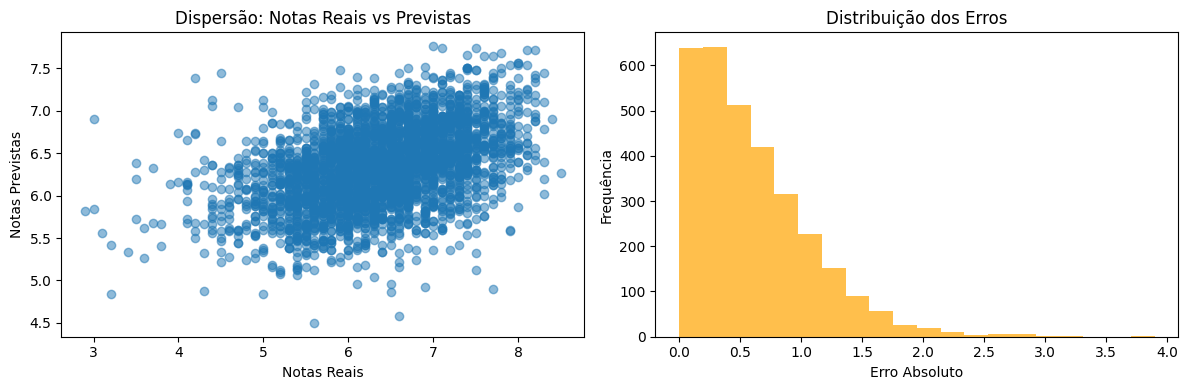


👉 Que tipo de filme você curte para uma boa recomendação (digite o nome do filme): Avengers: Age of Ultron

🎬 Recomendações (KNN) para 'Avengers: Age of Ultron':
- The Avengers
- Captain America: Civil War
- Iron Man 2
- Captain America: The Winter Soldier
- Thor: The Dark World

Deseja mais uma recomendação? (s/n): s

👉 Que tipo de filme você curte para uma boa recomendação (digite o nome do filme): Captain America: The Winter Soldier

🎬 Recomendações (KNN) para 'Captain America: The Winter Soldier':
- Captain America: Civil War
- The Avengers
- Avengers: Age of Ultron
- Iron Man 2
- Captain America: The First Avenger

Deseja mais uma recomendação? (s/n): s

👉 Que tipo de filme você curte para uma boa recomendação (digite o nome do filme): A Christmas Carol

🎬 Recomendações (KNN) para 'A Christmas Carol':
- The Scarlet Letter
- The Number 23
- Arthur Christmas
- Bridget Jones's Diary
- Quest for Camelot

Deseja mais uma recomendação? (s/n): s

👉 Que tipo de filme você curte para uma 

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_score, mean_squared_error, mean_absolute_error
from google.colab import files

print("Selecione o arquivo CSV da sua base de filmes:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

count = CountVectorizer(stop_words='english')
count_matrix = count.fit_transform(df['soup'].fillna(''))

knn = NearestNeighbors(n_neighbors=6, metric='cosine')
knn.fit(count_matrix)

def recomendar(titulo):
    try:
        idx = df[df['title'] == titulo].index[0]
        distances, indices = knn.kneighbors(count_matrix[idx])
        top_indices = indices[0][1:]

        print(f"\n🎬 Recomendações (KNN) para '{titulo}':")
        for i in top_indices:
            print(f"- {df['title'].iloc[i]}")
    except IndexError:
        print(f"\n❌ Filme '{titulo}' não encontrado.")
    except Exception as e:
        print(f"\nErro ao processar: {e}")

def avaliar_modelo(df, knn, count_matrix):
    y_true = []
    y_pred = []

    for idx in range(len(df)):
        distances, indices = knn.kneighbors(count_matrix[idx])
        top_indices = indices[0][1:]  # vizinhos mais próximos

        vizinhos_ratings = df.iloc[top_indices]['vote_average'].fillna(df['vote_average'].mean())
        pred_rating = vizinhos_ratings.mean()

        y_true.append(df.iloc[idx]['vote_average'])
        y_pred.append(pred_rating)

    # 🔹 Cálculo das métricas
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # Precisão binária (exemplo: relevante se nota >= 3.5)
    relevancia_real = [1 if r >= 3.5 else 0 for r in y_true]
    relevancia_pred = [1 if r >= 3.5 else 0 for r in y_pred]
    precisao = precision_score(relevancia_real, relevancia_pred)

    print(f"\n📊 Métricas de Avaliação:")
    print(f"Precisão: {precisao:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")

    # 🔹 Gráficos
    plt.figure(figsize=(12,4))

    # Gráfico 1: Dispersão entre notas reais e previstas
    plt.subplot(1,2,1)
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.xlabel("Notas Reais")
    plt.ylabel("Notas Previstas")
    plt.title("Dispersão: Notas Reais vs Previstas")

    # Gráfico 2: Distribuição dos erros absolutos
    erros = np.abs(np.array(y_true) - np.array(y_pred))
    plt.subplot(1,2,2)
    plt.hist(erros, bins=20, color='orange', alpha=0.7)
    plt.xlabel("Erro Absoluto")
    plt.ylabel("Frequência")
    plt.title("Distribuição dos Erros")

    plt.tight_layout()
    plt.show()


# 🔹 Executar Avaliação

avaliar_modelo(df, knn, count_matrix)

# 🔹 Loop interativo de recomendações
while True:
    titulo_usuario = input("\n👉 Que tipo de filme você curte para uma boa recomendação (digite o nome do filme): ")
    recomendar(titulo_usuario)

    continuar = input("\nDeseja mais uma recomendação? (s/n): ").strip().lower()
    if continuar != "s":
        print("\n✨ Espero que tenha curtido a recomendação!!!")
        break
